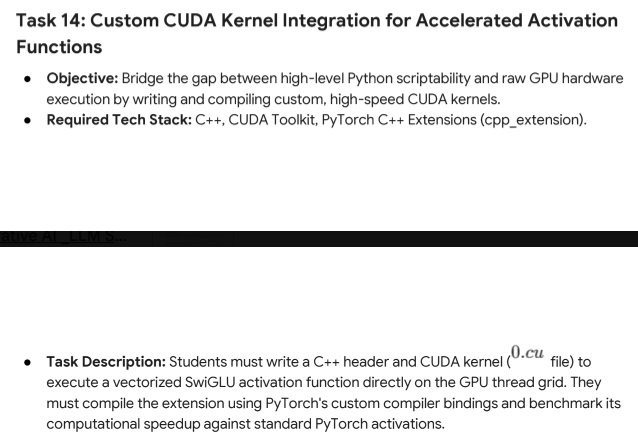

In [1]:
import torch

print("GPU available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("Please enable GPU in Colab.")

print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [2]:
!pip install -q ninja

from torch.utils.cpp_extension import load_inline

cuda_code = r'''
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_runtime.h>

__global__ void swiglu_kernel(
    const float* x,
    float* y,
    int n
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if (i < n) {
        float a = x[i];
        float b = x[i + n];

        float silu = a / (1.0f + expf(-a));

        y[i] = silu * b;
    }
}

torch::Tensor swiglu(torch::Tensor x) {

    int n = x.numel() / 2;

    auto y = torch::empty(
        {n},
        x.options()
    );

    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    swiglu_kernel<<<blocks, threads>>>(
        x.data_ptr<float>(),
        y.data_ptr<float>(),
        n
    );

    return y;
}

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
    m.def("swiglu", &swiglu);
}
'''

print("CUDA code ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 6.9 MB/s eta 0:00:00
CUDA code ready!


In [3]:
swiglu_cuda = load_inline(
    name="swiglu_simple",
    cpp_sources="",
    cuda_sources=cuda_code,
    functions=None,
    extra_cuda_cflags=["-O2"],
    verbose=False
)

print("CUDA kernel ready!")

CUDA kernel ready!


In [4]:
x = torch.randn(
    10000,
    device="cuda"
)

output = swiglu_cuda.swiglu(x)

print("Input size:", x.shape)
print("Output size:", output.shape)
print("Custom CUDA SwiGLU working!")

Input size: torch.Size([10000])
Output size: torch.Size([5000])
Custom CUDA SwiGLU working!


In [5]:
n = x.numel() // 2

a = x[:n]
b = x[n:]

pytorch_output = torch.nn.functional.silu(a) * b

difference = torch.max(
    torch.abs(output - pytorch_output)
)

print("Maximum difference:", difference.item())

Maximum difference: 0.0


In [6]:
import time

# CUDA
torch.cuda.synchronize()

start = time.time()

for _ in range(100):
    swiglu_cuda.swiglu(x)

torch.cuda.synchronize()

cuda_time = time.time() - start


# PyTorch
torch.cuda.synchronize()

start = time.time()

for _ in range(100):
    torch.nn.functional.silu(a) * b

torch.cuda.synchronize()

pytorch_time = time.time() - start


print("Custom CUDA:", round(cuda_time, 4), "seconds")
print("PyTorch:", round(pytorch_time, 4), "seconds")

Custom CUDA: 0.0028 seconds
PyTorch: 0.005 seconds


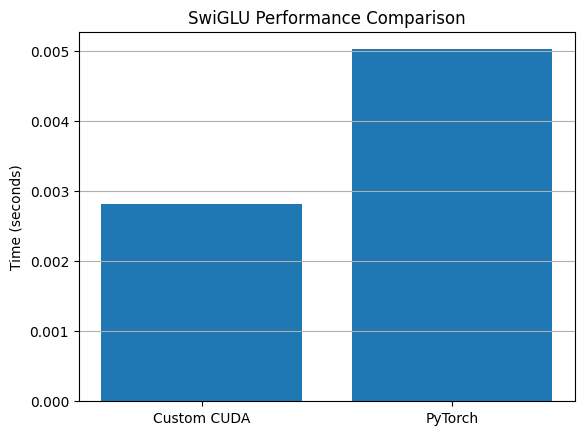

In [7]:
import matplotlib.pyplot as plt

plt.bar(
    ["Custom CUDA", "PyTorch"],
    [cuda_time, pytorch_time]
)

plt.ylabel("Time (seconds)")
plt.title("SwiGLU Performance Comparison")
plt.grid(axis="y")

plt.show()